In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import copy
import matplotlib.pyplot as plt
from torch.amp import autocast
from torch.cuda.amp import GradScaler


In [23]:
model = models.resnet18(pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(torch.cuda.is_available())
print(f"Using device: {torch.cuda.get_device_name(0)}")
print(model)


True
Using device: Tesla T4
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (

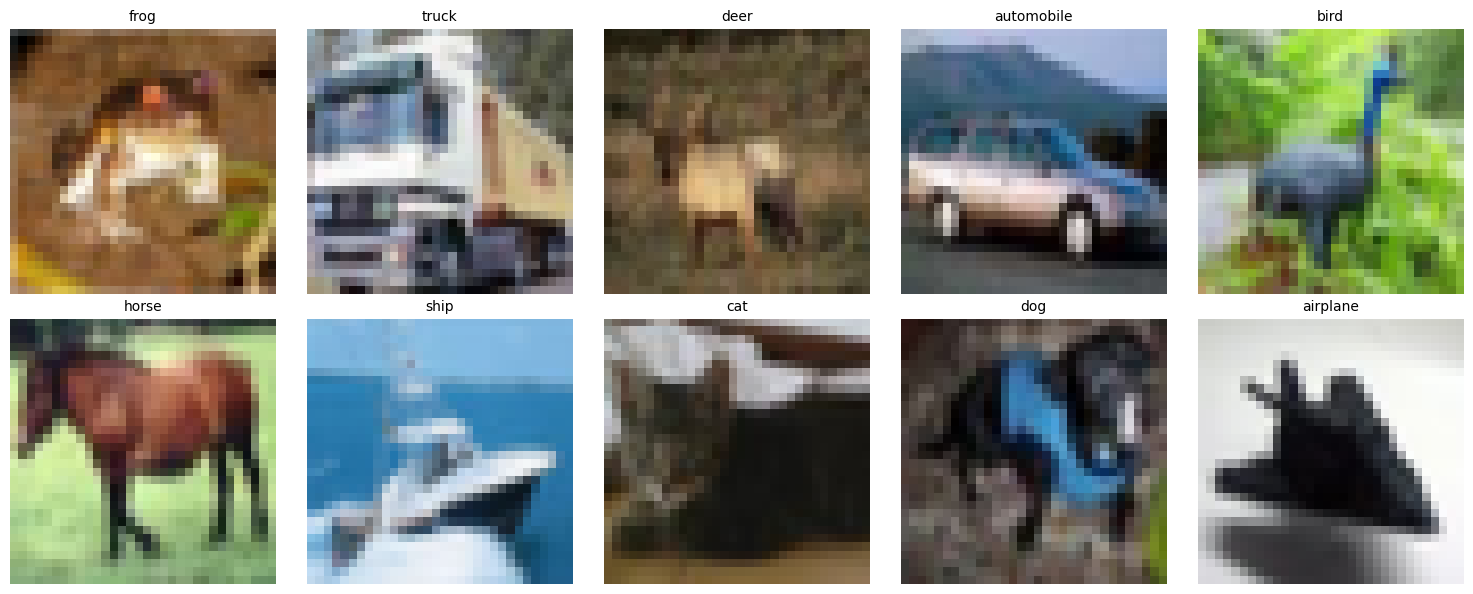

In [24]:
transform = transforms.Compose([transforms.ToTensor()])
cifar10 = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
classes = cifar10.classes  # ['airplane', 'automobile', ..., 'truck']

# Tạo dict lưu ảnh đầu tiên của mỗi lớp
images_by_class = {}
for img, label in cifar10:
    class_name = classes[label]
    if class_name not in images_by_class:
        images_by_class[class_name] = img
    if len(images_by_class) == 10:
        break

# Thay đổi: 2 hàng x 5 cột thay vì 1 hàng x 10 cột
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()  # Chuyển từ 2D array sang 1D để dễ iterate

for ax, (class_name, img_tensor) in zip(axes, images_by_class.items()):
    img = img_tensor.permute(1, 2, 0)  # Chuyển từ (C,H,W) sang (H,W,C)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Thay FC layer cho 10 classes
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Freeze tất cả layers trừ FC
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print(f"New final layer: {model.fc}")
model = model.to(device)

New final layer: Linear(in_features=512, out_features=10, bias=True)


In [26]:
# Transform: Resize về 224x224 (ResNet requirement) + Normalize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

In [27]:
# Download và load CIFAR-10
full_train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=transform)

train_size = int(0.9 * len(full_train_dataset))  # ~45,000
val_size = len(full_train_dataset) - train_size   # ~5,000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

In [28]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                         shuffle=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size,
                         shuffle=False, pin_memory=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
                        shuffle=False, pin_memory=True, num_workers=4)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 45000
Test samples: 10000
Batch size: 128


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

scaler = GradScaler()
writer = SummaryWriter('runs/resnet18_finetuning')

/tmp/ipython-input-2479842083.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [30]:
num_epochs = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0

In [31]:
# Cell 6: TRAINING LOOP
print("Training started...\n")

for epoch in range(num_epochs):
    # === TRAINING ===
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # === VALIDATION ===
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # === SAVE BEST MODEL ===
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # === LƯU HISTORY (QUAN TRỌNG!) ===
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # TensorBoard
    writer.add_scalars('Loss', {'Train': train_loss, 'Val': val_loss}, epoch)
    writer.add_scalars('Accuracy', {'Train': train_acc, 'Val': val_acc}, epoch)

writer.close()
print(f"\n Training completed! Best Val Acc: {best_acc:.2f}%")

Training started...

Epoch [1/20] - Train Loss: 0.9314, Train Acc: 71.00%, Val Acc: 78.00%
Epoch [2/20] - Train Loss: 0.6304, Train Acc: 78.70%, Val Acc: 79.54%
Epoch [3/20] - Train Loss: 0.5888, Train Acc: 79.88%, Val Acc: 80.00%
Epoch [4/20] - Train Loss: 0.5703, Train Acc: 80.35%, Val Acc: 80.28%
Epoch [5/20] - Train Loss: 0.5590, Train Acc: 80.62%, Val Acc: 80.78%
Epoch [6/20] - Train Loss: 0.5509, Train Acc: 80.86%, Val Acc: 80.38%
Epoch [7/20] - Train Loss: 0.5420, Train Acc: 81.06%, Val Acc: 80.58%
Epoch [8/20] - Train Loss: 0.5394, Train Acc: 81.19%, Val Acc: 80.70%
Epoch [9/20] - Train Loss: 0.5305, Train Acc: 81.56%, Val Acc: 81.08%
Epoch [10/20] - Train Loss: 0.5334, Train Acc: 81.38%, Val Acc: 80.22%
Epoch [11/20] - Train Loss: 0.5279, Train Acc: 81.71%, Val Acc: 80.78%
Epoch [12/20] - Train Loss: 0.5238, Train Acc: 81.91%, Val Acc: 80.42%
Epoch [13/20] - Train Loss: 0.5240, Train Acc: 81.71%, Val Acc: 80.96%
Epoch [14/20] - Train Loss: 0.5200, Train Acc: 81.83%, Val Acc: 8

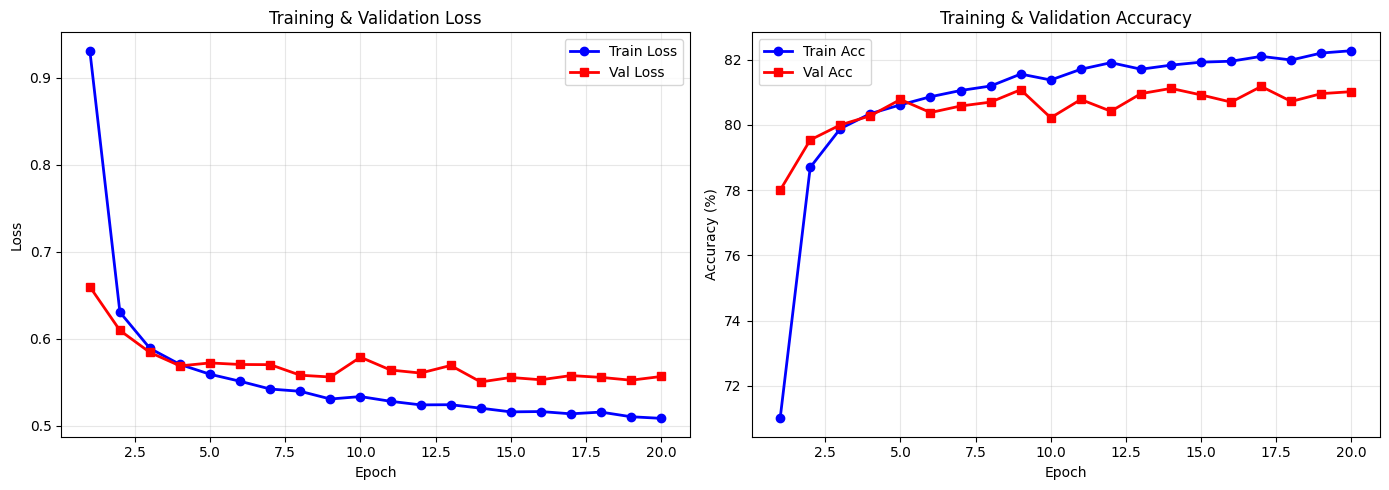

In [32]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
plt.plot(epochs_range, history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Biểu đồ 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
plt.plot(epochs_range, history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png') # Vẫn lưu file để backup
plt.show()

In [33]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast('cuda'):
            outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Final Test Accuracy: {test_accuracy:.2f}%")

Final Test Accuracy: 81.02%
